# Handwritten digits

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(r'C:\Users\ricca\Documents\Unimib-Code\AstroStatistics\Notebooks')
from Utilities import plot_settings

Import dataset

In [6]:
from sklearn import datasets
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


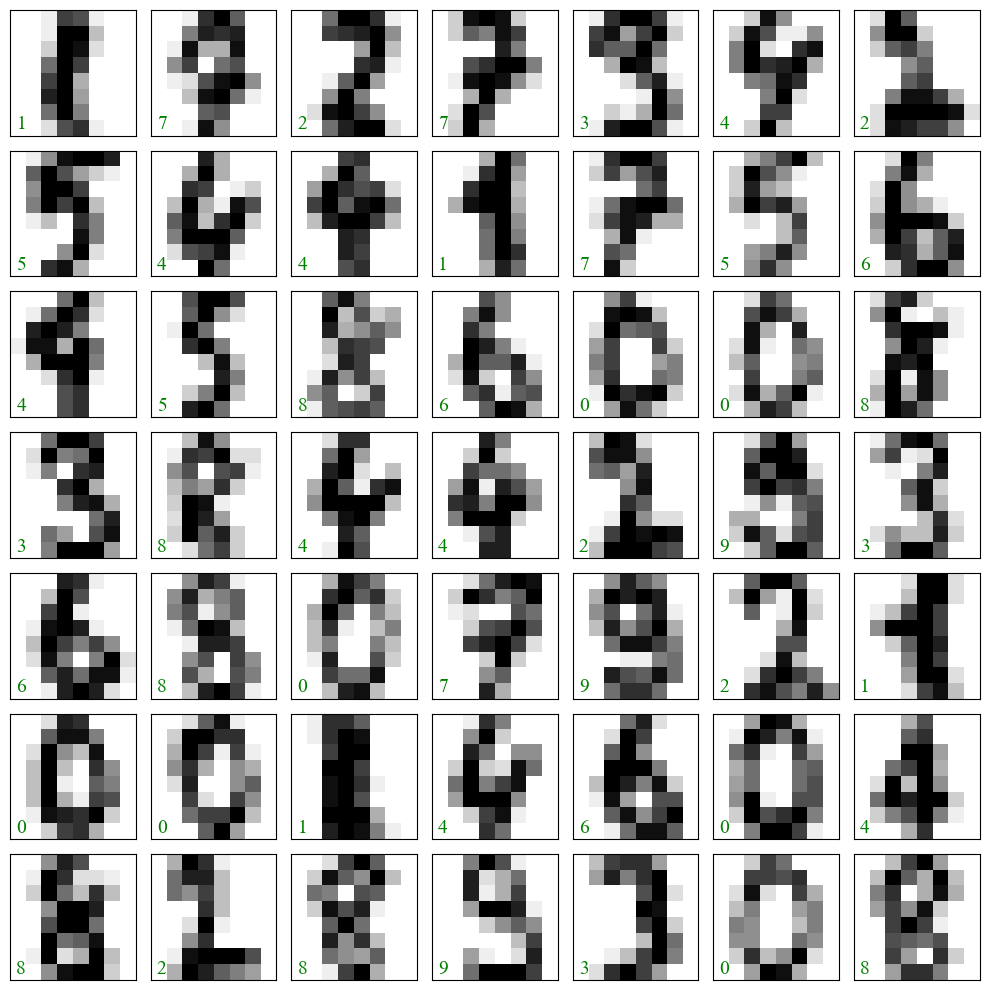

In [7]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, test_size=0.3, random_state=42, shuffle=True)

In [26]:
from sklearn.preprocessing import RobustScaler, StandardScaler
R = RobustScaler()
X_train_scaled = R.fit_transform(X_train)
X_test_scaled = R.transform(X_test)

In [27]:
X_train_scaled.shape, X_test_scaled.shape

((1257, 64), (540, 64))

In [28]:
from sklearn.decomposition import PCA
pca = PCA(n_components=64)

In [29]:
pca.fit(X_train_scaled)

,n_components,64
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


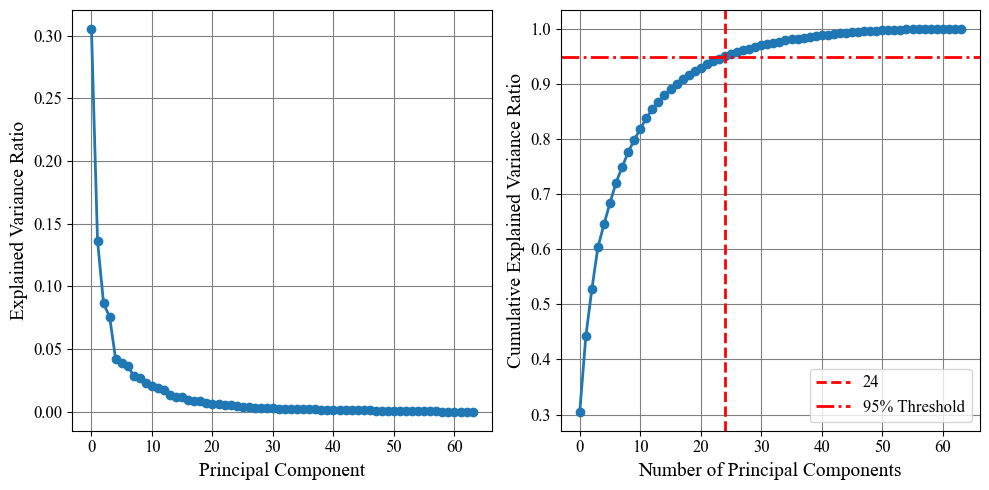

In [30]:
plt.subplot(1, 2, 1)
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')

plt.subplot(1, 2, 2)
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axvline(np.where(np.cumsum(pca.explained_variance_ratio_)>0.95)[0][0], color='red', linestyle='--', label=f'{np.where(np.cumsum(pca.explained_variance_ratio_)>0.95)[0][0]}')
plt.axhline(0.95, color='red', linestyle='-.', label='95% Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.legend()

In [31]:
pca = PCA(n_components=24)
X_train_tf = pca.fit_transform(X_train_scaled)
X_test_tf = pca.transform(X_test_scaled)

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
LR = LogisticRegression(max_iter=1000, random_state=42, solver='newton-cholesky')
LR.fit(X_train_tf, y_train)
labels = LR.predict(X_test_tf)

Text(0, 0.5, 'PC2')

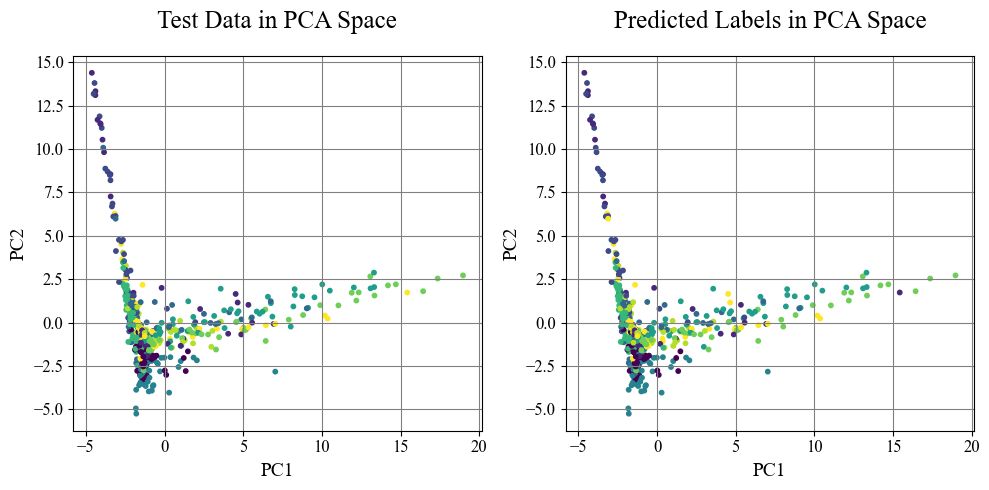

In [34]:
plt.subplot(1, 2, 1)
plt.scatter(X_test_tf[:, 0], X_test_tf[:, 1], c=y_test, cmap='viridis', s=10)
plt.title('Test Data in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.subplot(1, 2, 2)
plt.scatter(X_test_tf[:, 0], X_test_tf[:, 1], c=labels, cmap='viridis', s=10)
plt.title('Predicted Labels in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')

In [35]:
print(f'Accuracy :  {LR.score(X_test_tf, y_test)*100:.4} %')

Accuracy :  92.96 %


Locally Linear Embedding

In [36]:
from sklearn.manifold import LocallyLinearEmbedding, Isomap

In [37]:
LLE = LocallyLinearEmbedding(n_components=2, 
                             n_neighbors=10,
                             reg = 1e-3,
                             random_state=42)

In [38]:
LLE.fit(X_train_scaled)

,n_neighbors,10
,n_components,2
,reg,0.001
,eigen_solver,'auto'
,tol,1e-06
,max_iter,100
,method,'standard'
,hessian_tol,0.0001
,modified_tol,1e-12
,neighbors_algorithm,'auto'
,random_state,42


In [39]:
X_train_tf = LLE.fit_transform(X_train_scaled)
X_test_tf = LLE.fit_transform(X_test_scaled)

In [40]:
LR = LogisticRegression(max_iter=1000, random_state=42, solver='newton-cholesky')
LR.fit(X_train_tf, y_train)
labels = LR.predict(X_test_tf)

Text(0, 0.5, 'PC2')

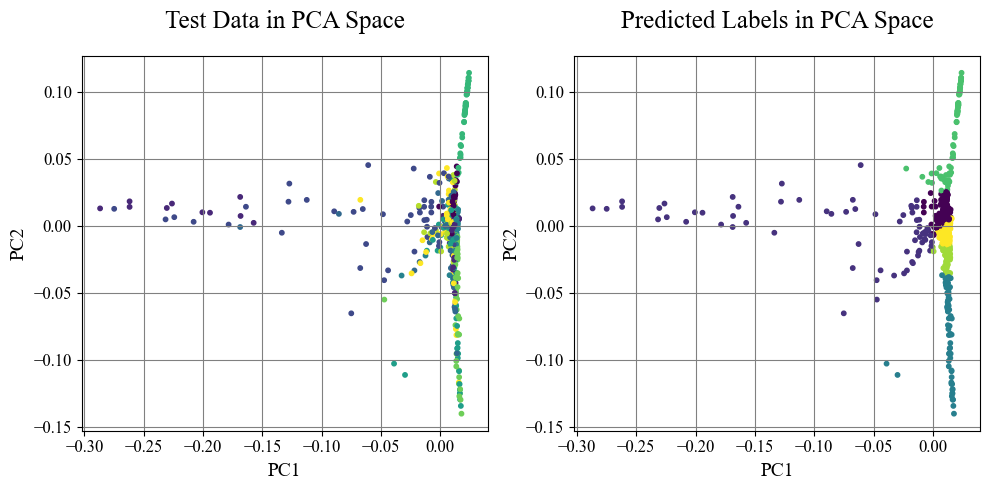

In [41]:
plt.subplot(1, 2, 1)
plt.scatter(X_test_tf[:, 0], X_test_tf[:, 1], c=y_test, cmap='viridis', s=10)
plt.title('Test Data in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.subplot(1, 2, 2)
plt.scatter(X_test_tf[:, 0], X_test_tf[:, 1], c=labels, cmap='viridis', s=10)
plt.title('Predicted Labels in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')

In [44]:
print(f'Accuracy : {LR.score(X_test_tf, y_test)*100:.3} %')

Accuracy : 22.0 %


In [46]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import Pipeline

In [50]:
pipe = Pipeline([
    ('LLE', LocallyLinearEmbedding(n_components=2)),
    ('LR', LogisticRegression())
])

params_grid = {
    'LLE__n_neighbors': list(np.linspace(5, 15, 4, dtype=int)),
    'LR__C': list(np.linspace(5, 15, 4, dtype=int))
}

custom_cv = KFold(n_splits=10, shuffle=True, random_state=134)

grid = GridSearchCV(pipe, params_grid, 
                    scoring='accuracy',  # or another classification metric
                    refit=True,
                    return_train_score=True,
                    cv=custom_cv,
                    verbose=3)

In [51]:
grid.fit(X_train_scaled, y_train)

Fitting 10 folds for each of 16 candidates, totalling 160 fits
[CV 1/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.225, test=0.151) total time=   0.2s
[CV 2/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.254, test=0.270) total time=   0.2s
[CV 3/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.439, test=0.468) total time=   0.2s
[CV 4/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.320, test=0.270) total time=   0.2s
[CV 5/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.391, test=0.365) total time=   0.1s
[CV 6/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.374, test=0.341) total time=   0.1s
[CV 7/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.410, test=0.365) total time=   0.1s
[CV 8/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.269, test=0.264) total time=   0.1s
[CV 9/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.252, test=0.208) total time=   0.2s
[CV 10/10] END LLE__n_neighbors=5, LR__C=5;, score=(train=0.181, test=0.152) total

,estimator,Pipeline(step...egression())])
,param_grid,"{'LLE__n_neighbors': [np.int64(5), np.int64(8), ...], 'LR__C': [np.int64(5), np.int64(8), ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_neighbors,np.int64(8)


In [52]:
print(f'Training accuracy : {grid.best_estimator_.score(X_train_scaled, y_train)*100:.4} %')
print(f'Test     accuracy : {grid.best_estimator_.score(X_test_scaled, y_test)*100:.4} %')

Training accuracy : 37.63 %
Test     accuracy : 32.96 %


In [53]:
pipe = Pipeline([
    ('ISO', Isomap(n_components=2)),
    ('LR', LogisticRegression(max_iter=10000))
])

params_grid = {
    'ISO__n_neighbors': list(np.linspace(5, 15, 4, dtype=int)),
    'LR__C': list(np.linspace(5, 15, 4, dtype=int))
}

custom_cv = KFold(n_splits=10, shuffle=True, random_state=134)

grid = GridSearchCV(pipe, params_grid, 
                    scoring='accuracy',  # or another classification metric
                    refit=True,
                    return_train_score=True,
                    cv=custom_cv,
                    verbose=3)

In [54]:
grid.fit(X_train_scaled, y_train);

Fitting 10 folds for each of 16 candidates, totalling 160 fits
[CV 1/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.573, test=0.619) total time=   0.9s
[CV 2/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.551, test=0.595) total time=   0.7s
[CV 3/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.569, test=0.532) total time=   0.7s
[CV 4/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.583, test=0.540) total time=   0.8s
[CV 5/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.584, test=0.635) total time=   0.8s
[CV 6/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.592, test=0.619) total time=   1.0s
[CV 7/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.613, test=0.540) total time=   1.1s
[CV 8/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.594, test=0.544) total time=   0.7s
[CV 9/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.582, test=0.600) total time=   0.6s
[CV 10/10] END ISO__n_neighbors=5, LR__C=5;, score=(train=0.553, test=0.512) total

In [55]:
grid.best_estimator_

,steps,"[('ISO', ...), ('LR', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_neighbors,np.int64(5)
,radius,None
,n_components,2
,eigen_solver,'auto'
,tol,0
,max_iter,None
,path_method,'auto'


In [56]:
print(f'Training accuracy : {grid.best_estimator_.score(X_train_scaled, y_train)*100:.4} %')
print(f'Test     accuracy : {grid.best_estimator_.score(X_test_scaled, y_test)*100:.4} %')

Training accuracy : 58.31 %
Test     accuracy : 60.19 %


In [57]:
grid.best_params_

{'ISO__n_neighbors': np.int64(5), 'LR__C': np.int64(5)}

In [58]:
ISO = Isomap(n_components=2, n_neighbors=5)
X_test_tf = ISO.fit_transform(X_test)
X_train_tf = ISO.fit_transform(X_train)
LR = LogisticRegression(C=5, max_iter=10000)
LR.fit(X_train_tf, y_train)
labels = LR.predict(X_test_tf)

c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\ricca\Documents\Unimib-Code\AstroStatistics\tf-venv\lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


Text(0, 0.5, 'PC2')

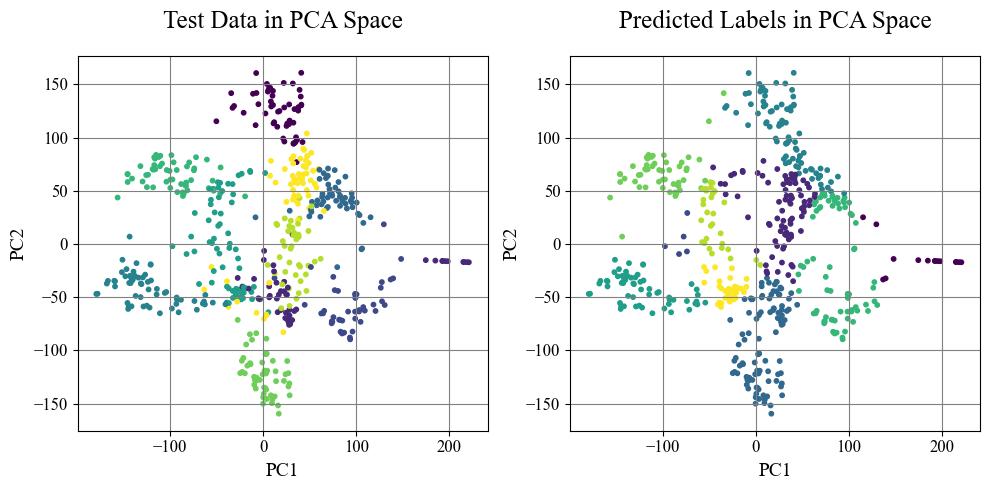

In [59]:
plt.subplot(1, 2, 1)
plt.scatter(X_test_tf[:, 0], X_test_tf[:, 1], c=y_test, cmap='viridis', s=10)
plt.title('Test Data in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.subplot(1, 2, 2)
plt.scatter(X_test_tf[:, 0], X_test_tf[:, 1], c=labels, cmap='viridis', s=10)
plt.title('Predicted Labels in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')

In [129]:
from sklearn.manifold import TSNE

In [130]:
T = TSNE(n_components=2,
         learning_rate = 200,
         max_iter=10000
         )

In [133]:
scaled = R.fit_transform(digits.data)

In [ ]:
ts = T.fit_transform(scaled)

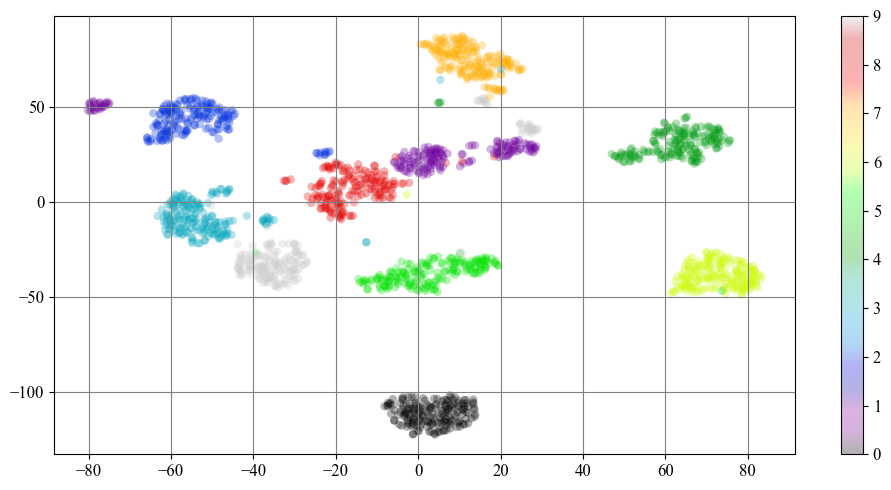

In [137]:
plt.scatter(ts[:,0],ts[:,1], 
            c=digits.target, cmap="nipy_spectral", alpha=0.3, 
            edgecolor="None")
plt.colorbar()

In [138]:
from sklearn.neighbors import KNeighborsClassifier

In [147]:
X_train, X_test, y_train, y_test = train_test_split(ts, digits.target, test_size=0.3, shuffle=True, random_state=42)

In [148]:
KNN = KNeighborsClassifier(n_neighbors=7,
                           weights='distance',
                           algorithm='auto',
                           p=2
                           )

In [149]:
KNN.fit(X_train, y_train)

,n_neighbors,7
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [151]:
predicted = KNN.predict(X_test)
KNN.score(X_test, y_test)

0.9851851851851852

Text(0, 0.5, 'PC2')

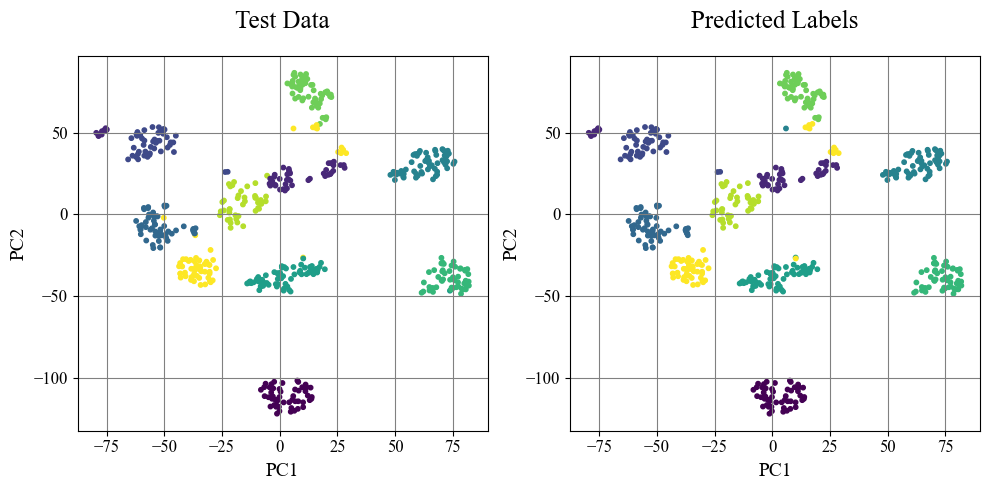

In [152]:
plt.subplot(1, 2, 1)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', s=10)
plt.title('Test Data')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 0], X_test[:, 1], c=predicted, cmap='viridis', s=10)
plt.title('Predicted Labels')
plt.xlabel('PC1')
plt.ylabel('PC2')

In [153]:
from matplotlib import offsetbox

def plot_embedding(X, y):
    x_min, x_max = np.min(X, 0), np.max(X, 0)
    X = (X - x_min) / (x_max - x_min)

    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111)
    for i in range(X.shape[0]):
        plt.text(X[i, 0], X[i, 1], str(digits.target[i]), 
                 color=plt.cm.nipy_spectral(y[i]/9.))

    shown_images = np.array([[1., 1.]])  # just something big
    for i in range(digits.data.shape[0]):
        dist = np.sum((X[i] - shown_images) ** 2, 1)
        if np.min(dist) < 4e-3:
            # don't show points that are too close
            continue
        shown_images = np.r_[shown_images, [X[i]]]
        imagebox = offsetbox.AnnotationBbox(
            offsetbox.OffsetImage(digits.images[i],
                                  cmap=plt.cm.gray_r), 
            X[i])
        ax.add_artist(imagebox)
    plt.xticks([]), plt.yticks([])

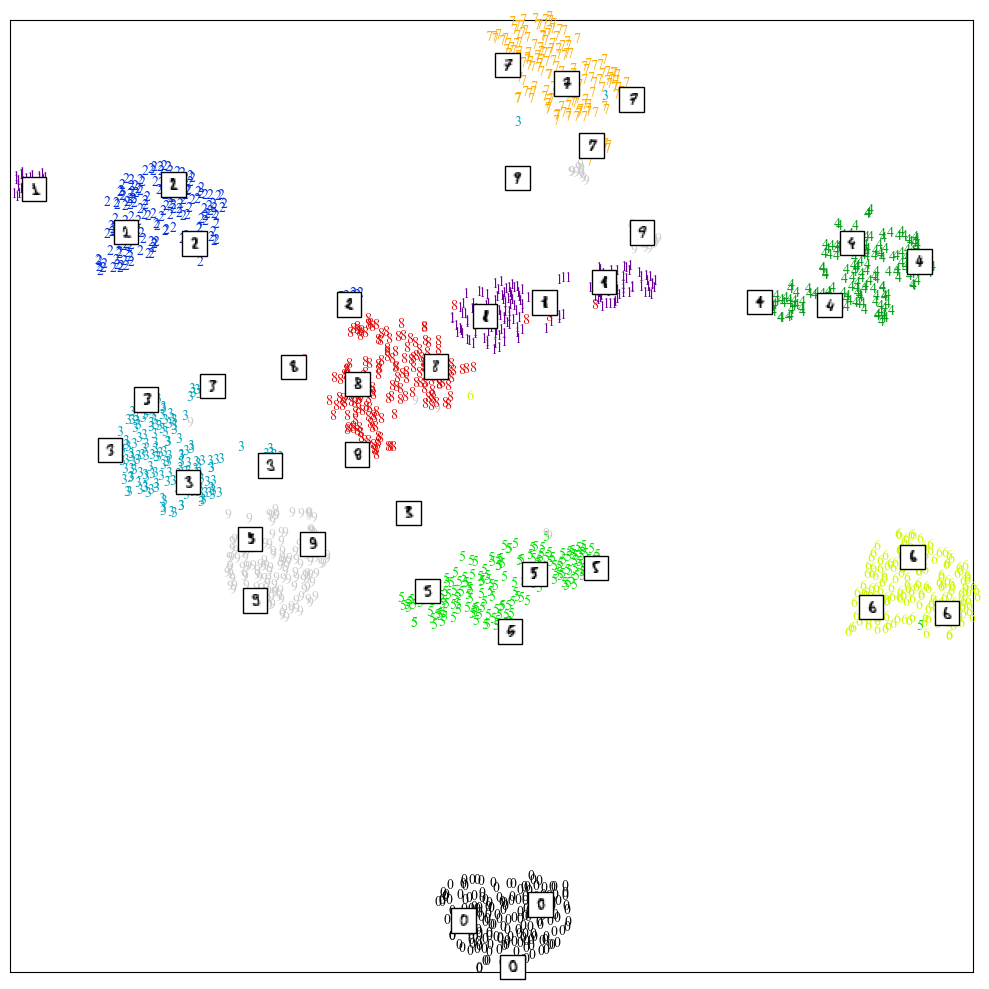

In [155]:
plot_embedding(ts, digits.target)